Accuracy: 0.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     295.0
           3       0.00      0.00      0.00    1145.0
           4       0.00      0.00      0.00       0.0
           5       0.00      0.00      0.00   61757.0

    accuracy                           0.00   63197.0
   macro avg       0.00      0.00      0.00   63197.0
weighted avg       0.00      0.00      0.00   63197.0



C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lenovo\anaconda3\Lib\site-packages\s

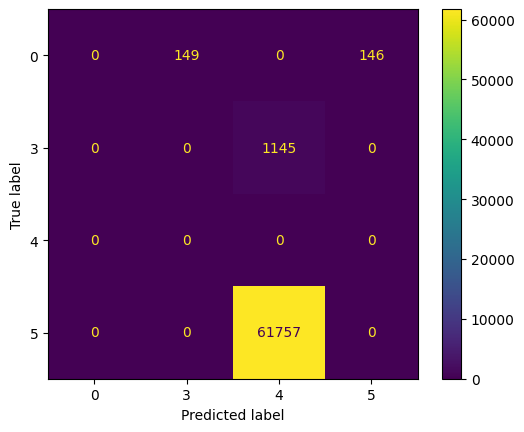

Cross-validation Accuracy: 0.9786622897004514


In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVC

import matplotlib.pyplot as plt


# ==============================
# LOAD DATA
# ==============================

normal = pd.read_csv("Normal_data.csv")
meta = pd.read_csv("metasploitable-2.csv")
ovs = pd.read_csv("OVS.csv")

train_df = pd.concat([normal, ovs], axis=0)
test_df = meta.copy()

train_df.drop_duplicates(inplace=True)
train_df.dropna(inplace=True)

test_df.drop_duplicates(inplace=True)
test_df.dropna(inplace=True)


# ==============================
# REMOVE SMALL CLASSES
# ==============================

counts = train_df["Label"].value_counts()
valid_classes = counts[counts > 50].index

train_df = train_df[train_df["Label"].isin(valid_classes)]
test_df = test_df[test_df["Label"].isin(valid_classes)]


# ==============================
# ENCODE
# ==============================

le = LabelEncoder()

for col in train_df.columns:
    if train_df[col].dtype == 'object':
        le.fit(pd.concat([train_df[col], test_df[col]]))
        train_df[col] = le.transform(train_df[col])
        test_df[col] = le.transform(test_df[col])


X_train = train_df.drop("Label", axis=1)
y_train = train_df["Label"]

X_test = test_df.drop("Label", axis=1)
y_test = test_df["Label"]


# ==============================
# SCALE + PCA
# ==============================

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=15)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


# ==============================
# ⭐ MLP FEATURE EXTRACTOR
# ==============================

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=50,
    random_state=42
)

mlp.fit(X_train_pca, X_train_pca)

X_train_mlp = mlp.predict(X_train_pca)
X_test_mlp = mlp.predict(X_test_pca)


# ==============================
# ⭐ SVM CLASSIFIER
# ==============================

svm = SVC(
    kernel='rbf',
    C=5,
    gamma='scale'
)

svm.fit(X_train_mlp, y_train)

y_pred = svm.predict(X_test_mlp)


# ==============================
# RESULTS
# ==============================

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


scores = cross_val_score(svm, X_train_mlp, y_train, cv=5)
print("Cross-validation Accuracy:", scores.mean())


Cross-validation Accuracy: 0.978531946221246

CROSS-VALIDATION METRICS

Precision: 0.9806503162817881
Recall: 0.978531946221246
F1 Score: 0.978770619669987


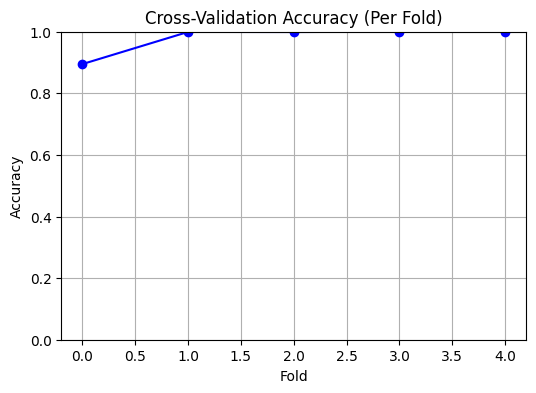

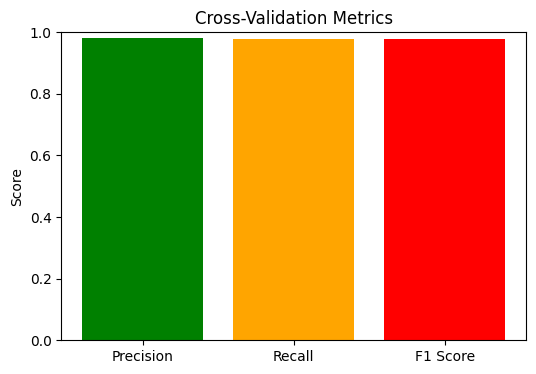

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# ==============================
# PIPELINE (same as CV)
# ==============================
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=15)),
    ('svm', SVC(kernel='rbf', C=5, gamma='scale'))
])

# ==============================
# CROSS VALIDATION SCORES
# ==============================
scores = cross_val_score(pipeline, X_train, y_train, cv=5)

print("Cross-validation Accuracy:", scores.mean())

# ==============================
# CROSS VALIDATION PREDICTIONS
# (IMPORTANT for precision/recall/f1)
# ==============================
y_cv_pred = cross_val_predict(pipeline, X_train, y_train, cv=5)

# ==============================
# METRICS
# ==============================
precision = precision_score(y_train, y_cv_pred, average='weighted')
recall = recall_score(y_train, y_cv_pred, average='weighted')
f1 = f1_score(y_train, y_cv_pred, average='weighted')

print("\nCROSS-VALIDATION METRICS\n")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# ==============================
# GRAPH 1: CV ACCURACY PER FOLD
# ==============================
plt.figure(figsize=(6,4))
plt.plot(scores, marker='o', color='blue')
plt.title("Cross-Validation Accuracy (Per Fold)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.grid()
plt.show()

# ==============================
# GRAPH 2: METRICS BAR GRAPH
# ==============================
metrics = [precision, recall, f1]
labels = ["Precision", "Recall", "F1 Score"]

plt.figure(figsize=(6,4))
plt.bar(labels, metrics, color=['green','orange','red'])
plt.ylim(0,1)
plt.title("Cross-Validation Metrics")
plt.ylabel("Score")
plt.show()